In [1]:
import os
from pathlib import Path

ROOT_DIR_BRAINTREEBANK = Path(r"C:\Users\simon\PyCharmMiscProject\neuroprobe-dev\braintreebank")
os.environ["ROOT_DIR_BRAINTREEBANK"] = str(ROOT_DIR_BRAINTREEBANK)

assert ROOT_DIR_BRAINTREEBANK.exists(), ROOT_DIR_BRAINTREEBANK

In [2]:
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import neuroprobe
from neuroprobe import (
    BrainTreebankSubject,
    BrainTreebankSubjectTrialBenchmarkDataset,
    generate_splits_cross_session,
    generate_splits_cross_subject,
    generate_splits_within_session,
)

<module 'torch' from 'C:\\ProgramData\\anaconda3\\envs\\neuro\\Lib\\site-packages\\torch\\__init__.py'>
C:\ProgramData\anaconda3\envs\neuro\Lib\site-packages\torch\__init__.py
['AVG', 'AcceleratorError', 'AggregationType', 'AliasDb', 'AnyType', 'Argument', 'ArgumentSpec', 'AwaitType', 'BFloat16Storage', 'BFloat16Tensor', 'BenchmarkConfig', 'BenchmarkExecutionStats', 'Block', 'BoolStorage', 'BoolTensor', 'BoolType', 'BufferDict', 'ByteStorage', 'ByteTensor', 'CallStack', 'Capsule', 'CharStorage', 'CharTensor', 'ClassType', 'Code', 'CompilationUnit', 'CompleteArgumentSpec', 'ComplexDoubleStorage', 'ComplexFloatStorage', 'ComplexType', 'ConcreteModuleType', 'ConcreteModuleTypeBuilder', 'DeepCopyMemoTable', 'DeserializationStorageContext', 'DeviceObjType', 'DictType', 'DisableTorchFunction', 'DisableTorchFunctionSubclass', 'DispatchKey', 'DispatchKeySet']
2.12.1+cpu


In [3]:
import neuroprobe.config as neuroprobe_config

print("BrainTreebank root:", ROOT_DIR_BRAINTREEBANK)
print("Neuroprobe ROOT_DIR:", neuroprobe_config.ROOT_DIR)
print("Sampling rate:", neuroprobe_config.SAMPLING_RATE, "Hz")

# Subject setup
subject_id = 1
trial_id = 1
coordinates_type = "mni"  # "mni", "mni305", "cortical", "lpi"

subject = BrainTreebankSubject(
    subject_id=subject_id,
    allow_corrupted=False,
    cache=True,
    dtype=torch.float32,
    coordinates_type=coordinates_type,
)
print("Loaded subject", subject_id)
print("First 10 electrode labels:", subject.electrode_labels[:10])
print("First 10 electrode MNI coordinates:")
print(subject.get_electrode_coordinates()[:10])

# Benchmark dataset setup
eval_name = "volume"
output_indices = False
start_neural_data_before_word_onset = 0
end_neural_data_after_word_onset = neuroprobe_config.SAMPLING_RATE * 1  # 1 second

benchmark_dataset = BrainTreebankSubjectTrialBenchmarkDataset(
    subject,
    trial_id,
    dtype=torch.float32,
    eval_name=eval_name,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True,
)

data_electrode_labels = benchmark_dataset.electrode_labels
data_electrode_coordinates = benchmark_dataset.electrode_coordinates

print("Dataset type:", type(benchmark_dataset))
print("Dataset length:", len(benchmark_dataset))

first_item = benchmark_dataset[0]
print("First item type:", type(first_item))
print("First item:", first_item)

if isinstance(first_item, dict):
    print("First item data shape:", first_item["data"].shape)
    print("First item label:", first_item["label"])
else:
    print("First item shape:", first_item[0].shape)
    print("First item label:", first_item[1])

print("Number of electrodes in dataset:", len(data_electrode_labels))

BrainTreebank root: C:\Users\simon\PyCharmMiscProject\neuroprobe-dev\braintreebank
Neuroprobe ROOT_DIR: C:\Users\simon\PyCharmMiscProject\neuroprobe-dev\braintreebank
Sampling rate: 2048 Hz
Loaded subject 1
First 10 electrode labels: ['F3aOFa2', 'F3aOFa3', 'F3aOFa4', 'F3aOFa7', 'F3aOFa8', 'F3aOFa9', 'F3aOFa10', 'F3aOFa11', 'F3aOFa12', 'F3aOFa13']
First 10 electrode MNI coordinates:
tensor([[  8.0828,  44.3820, -15.1744],
        [ 12.4152,  43.6956, -14.8598],
        [ 15.7043,  42.0086, -13.4021],
        [ 27.5911,  38.1577,  -9.0090],
        [ 30.7824,  37.5062,  -7.6428],
        [ 35.1301,  35.9065,  -6.1294],
        [ 38.4192,  34.2195,  -4.6717],
        [ 42.6692,  33.6553,  -3.2497],
        [ 45.9583,  31.9683,  -1.7920],
        [ 50.2907,  31.2818,  -1.4774]])
Dataset type: <class 'neuroprobe.datasets.BrainTreebankSubjectTrialBenchmarkDataset'>
Dataset length: 3500
First item type: <class 'dict'>
First item: {'data': tensor([[ 32.9645,  27.3818,  20.4699,  ...,   2.1267,

In [4]:
import neuroprobe.train_test_splits as neuroprobe_train_test_splits

folds = neuroprobe_train_test_splits.generate_splits_within_session(
    subject,
    trial_id,
    eval_name,
    dtype=torch.float32,
    output_indices=output_indices,
    start_neural_data_before_word_onset=start_neural_data_before_word_onset,
    end_neural_data_after_word_onset=end_neural_data_after_word_onset,
    lite=True,
)

fold_idx = 0
fold = folds[fold_idx]
train_dataset = fold["train_dataset"]
test_dataset = fold["test_dataset"]

def dataset_to_features(ds):
    X_rows = []
    y_rows = []
    for item in ds:
        # item is a dict: {'data': ..., 'label': ..., ...}
        if isinstance(item, dict):
            x = item["data"]
            y = item["label"]
        else:
            x = item[0]
            y = item[1]

        x_np = x.numpy() if torch.is_tensor(x) else np.asarray(x)  # (n_electrodes, n_samples)

        # Summary features per electrode
        mean_per_electrode = x_np.mean(axis=1)   # shape: (n_electrodes,)
        std_per_electrode = x_np.std(axis=1)    # shape: (n_electrodes,)
        max_per_electrode = x_np.max(axis=1)    # shape: (n_electrodes,)

        features = np.concatenate([
            mean_per_electrode,
            std_per_electrode,
            max_per_electrode,
        ])  # shape: (3 * n_electrodes,)

        X_rows.append(features)
        y_rows.append(float(y))

    X = np.stack(X_rows)               # (n_examples, 3 * n_electrodes)
    y = np.array(y_rows, dtype=np.float32)
    return X, y

X_train, y_train = dataset_to_features(train_dataset)
X_test, y_test = dataset_to_features(test_dataset)

print("Compressed X_train shape:", X_train.shape)
print("Compressed X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Compressed X_train shape: (1750, 360)
Compressed X_test shape: (875, 360)
y_train shape: (1750,)
y_test shape: (875,)


In [5]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

alphas = np.logspace(-2, 3, 6)

ridge_cv = Pipeline(
    steps=[
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("ridge", RidgeCV(alphas=alphas)),
    ]
)

ridge_cv.fit(X_train, y_train)
best_alpha = ridge_cv.named_steps["ridge"].alpha_
print("Best alpha:", best_alpha)

y_train_pred = ridge_cv.predict(X_train)
y_test_pred = ridge_cv.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train R^2 (compressed): {train_r2:.3f}")
print(f"Test R^2 (compressed):  {test_r2:.3f}")

Best alpha: 100.0
Train R^2 (compressed): 0.525
Test R^2 (compressed):  -0.679


It's almost obvious the no linear model will be able to make any significant progress. Let's jump right to a baseline CNN. Basically this is a classic high-variance problem, there's no way a linear model will perform well.

In [6]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class NeuroprobeTorchDataset(Dataset):
    def __init__(self, ds):
        self.ds = ds

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]

        if isinstance(item, dict):
            x = item["data"]
            y = item["label"]
        else:
            x = item[0]
            y = item[1]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        else:
            x = x.to(torch.float32)

        y = torch.tensor(float(y), dtype=torch.float32)
        return x, y


train_torch_ds = NeuroprobeTorchDataset(train_dataset)
test_torch_ds = NeuroprobeTorchDataset(test_dataset)

train_loader = DataLoader(train_torch_ds, batch_size=16, shuffle=True, num_workers=0)
test_loader = DataLoader(test_torch_ds, batch_size=16, shuffle=False, num_workers=0)

sample_x, sample_y = train_torch_ds[0]
print("Sample x shape:", sample_x.shape)  # (n_electrodes, time)
print("Sample y:", sample_y)

Using device: cpu
Sample x shape: torch.Size([120, 2048])
Sample y: tensor(1.)


In [7]:
class EEGCNNRegressor(nn.Module):
    def __init__(self, n_electrodes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv1d(n_electrodes, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x.squeeze(-1)


n_electrodes = sample_x.shape[0]
model = EEGCNNRegressor(n_electrodes=n_electrodes).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(model)

EEGCNNRegressor(
  (features): Sequential(
    (0): Conv1d(120, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(64, 128, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (regressor): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=Fa

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)  # shape: (batch, n_electrodes, time)
        y = y.to(device)

        optimizer.zero_grad()
        preds = model(x)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_y = []
    all_preds = []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        preds = model(x)
        loss = criterion(preds, y)

        total_loss += loss.item() * x.size(0)
        all_y.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)
    r2 = r2_score(y_true, y_pred)

    return total_loss / len(loader.dataset), r2, y_true, y_pred

In [9]:
num_epochs = 10

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test R^2: {test_r2:.4f}"
    )

Epoch 01 | Train Loss: 0.2300 | Test Loss: 0.2554 | Test R^2: -0.0214
Epoch 02 | Train Loss: 0.1769 | Test Loss: 0.2892 | Test R^2: -0.1566
Epoch 03 | Train Loss: 0.1484 | Test Loss: 0.2825 | Test R^2: -0.1299
Epoch 04 | Train Loss: 0.1386 | Test Loss: 0.2932 | Test R^2: -0.1728
Epoch 05 | Train Loss: 0.1294 | Test Loss: 0.2654 | Test R^2: -0.0617
Epoch 06 | Train Loss: 0.1159 | Test Loss: 0.2683 | Test R^2: -0.0733
Epoch 07 | Train Loss: 0.0996 | Test Loss: 0.3164 | Test R^2: -0.2658
Epoch 08 | Train Loss: 0.0967 | Test Loss: 0.2741 | Test R^2: -0.0962
Epoch 09 | Train Loss: 0.0933 | Test Loss: 0.2993 | Test R^2: -0.1972
Epoch 10 | Train Loss: 0.0889 | Test Loss: 0.3326 | Test R^2: -0.3303


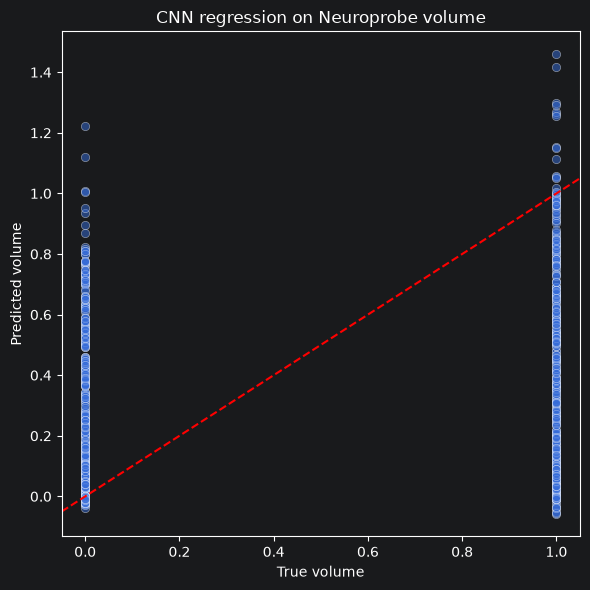

In [10]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)
plt.xlabel("True volume")
plt.ylabel("Predicted volume")
plt.title("CNN regression on Neuroprobe volume")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.tight_layout()
plt.show()

The basic CNN is still worse than using the mean. I'm going to try these new changes:
1: reduce channels 64 --> 32 as it's obviously overfitting
2: Increase wieght decay
3: add early stopping
4: add an embedding per electrode and add time-series

In [11]:
class ElectrodeEmbeddingCNNRegressor(nn.Module):
    def __init__(self, n_electrodes, emb_dim=16, hidden_channels=32):
        super().__init__()

        self.n_electrodes = n_electrodes
        self.emb_dim = emb_dim

        # Learn one embedding vector per electrode
        self.electrode_embedding = nn.Embedding(n_electrodes, emb_dim)

        # Turn each embedding into a scalar gate for that electrode
        self.electrode_gate = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, 1),
            nn.Sigmoid(),
        )

        # Small temporal CNN
        self.temporal_net = nn.Sequential(
            nn.Conv1d(n_electrodes, hidden_channels, kernel_size=9, padding=4),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_channels),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(hidden_channels, hidden_channels * 2, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden_channels * 2),
            nn.ReLU(),

            nn.AdaptiveAvgPool1d(1),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_channels * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x: (batch, n_electrodes, time)
        batch_size = x.shape[0]
        device = x.device

        electrode_ids = torch.arange(self.n_electrodes, device=device)  # (n_electrodes,)
        emb = self.electrode_embedding(electrode_ids)  # (n_electrodes, emb_dim)
        gates = self.electrode_gate(emb).squeeze(-1)  # (n_electrodes,)
        gates = gates.view(1, self.n_electrodes, 1)  # (1, n_electrodes, 1)

        # Electrode-specific scaling
        x = x * gates

        x = self.temporal_net(x)
        x = self.regressor(x)
        return x.squeeze(-1)

In [12]:
n_electrodes = sample_x.shape[0]
model = ElectrodeEmbeddingCNNRegressor(
    n_electrodes=n_electrodes,
    emb_dim=16,
    hidden_channels=32,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-3)

print(model)

ElectrodeEmbeddingCNNRegressor(
  (electrode_embedding): Embedding(120, 16)
  (electrode_gate): Sequential(
    (0): Linear(in_features=16, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
  (temporal_net): Sequential(
    (0): Conv1d(120, 32, kernel_size=(9,), stride=(1,), padding=(4,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=Tr

In [13]:
num_epochs = 50
best_test_r2 = -np.inf
best_state_dict = None
history = []

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "test_r2": test_r2,
    })

    if test_r2 > best_test_r2:
        best_test_r2 = test_r2
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test R^2: {test_r2:.4f} | "
        f"Best Test R^2: {best_test_r2:.4f}"
    )

Epoch 01 | Train Loss: 0.2540 | Test Loss: 0.2531 | Test R^2: -0.0122 | Best Test R^2: -0.0122
Epoch 02 | Train Loss: 0.1883 | Test Loss: 0.2879 | Test R^2: -0.1515 | Best Test R^2: -0.0122
Epoch 03 | Train Loss: 0.1565 | Test Loss: 0.2553 | Test R^2: -0.0211 | Best Test R^2: -0.0122
Epoch 04 | Train Loss: 0.1396 | Test Loss: 0.2684 | Test R^2: -0.0736 | Best Test R^2: -0.0122
Epoch 05 | Train Loss: 0.1286 | Test Loss: 0.2735 | Test R^2: -0.0941 | Best Test R^2: -0.0122
Epoch 06 | Train Loss: 0.1157 | Test Loss: 0.2765 | Test R^2: -0.1059 | Best Test R^2: -0.0122
Epoch 07 | Train Loss: 0.1101 | Test Loss: 0.2656 | Test R^2: -0.0624 | Best Test R^2: -0.0122
Epoch 08 | Train Loss: 0.1085 | Test Loss: 0.2631 | Test R^2: -0.0523 | Best Test R^2: -0.0122
Epoch 09 | Train Loss: 0.0964 | Test Loss: 0.2779 | Test R^2: -0.1118 | Best Test R^2: -0.0122
Epoch 10 | Train Loss: 0.0865 | Test Loss: 0.2724 | Test R^2: -0.0894 | Best Test R^2: -0.0122
Epoch 11 | Train Loss: 0.0847 | Test Loss: 0.2733 

In [14]:
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

test_loss, test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)
print(f"Restored best model | Test Loss: {test_loss:.4f} | Test R^2: {test_r2:.4f}")

Restored best model | Test Loss: 0.2531 | Test R^2: -0.0122


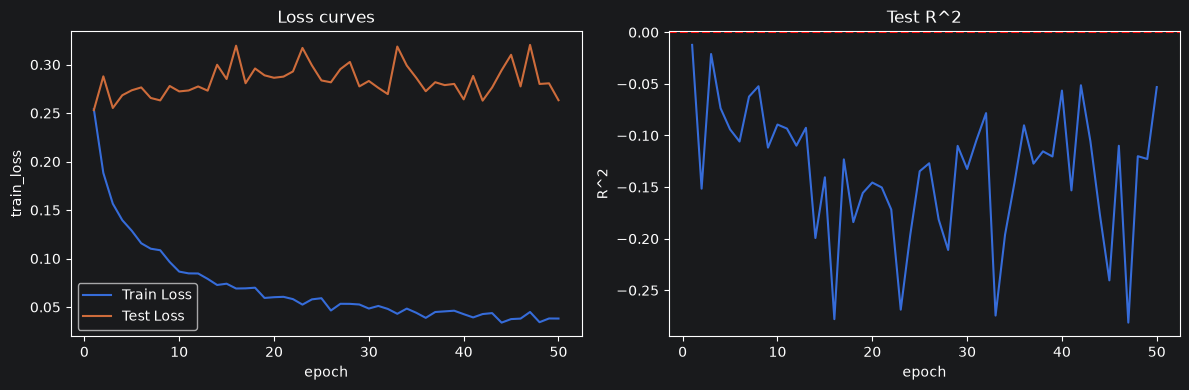

In [15]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=history_df, x="epoch", y="train_loss", ax=axes[0], label="Train Loss")
sns.lineplot(data=history_df, x="epoch", y="test_loss", ax=axes[0], label="Test Loss")
axes[0].set_title("Loss curves")

sns.lineplot(data=history_df, x="epoch", y="test_r2", ax=axes[1])
axes[1].axhline(0.0, color="red", linestyle="--")
axes[1].set_title("Test R^2")
axes[1].set_ylabel("R^2")

plt.tight_layout()
plt.show()

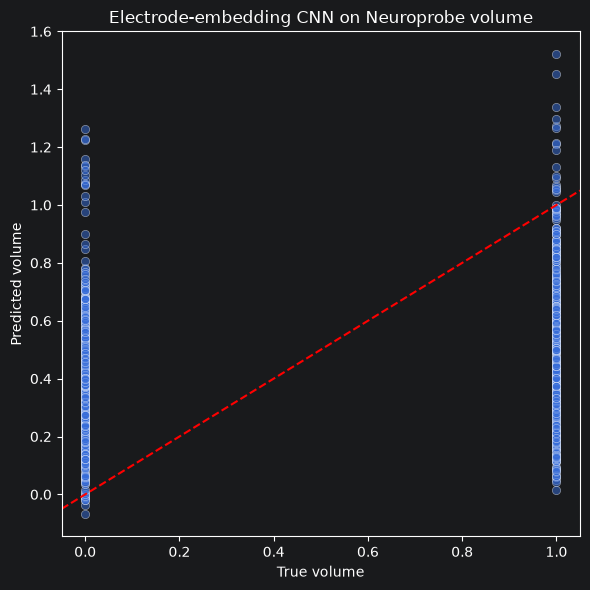

In [16]:
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)
plt.xlabel("True volume")
plt.ylabel("Predicted volume")
plt.title("Electrode-embedding CNN on Neuroprobe volume")
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.tight_layout()
plt.show()

# New Changes
Run all within-session folds, not just fold_idx = 0.

Replace the pure channel-CNN with an electrode-token model:

per-electrode temporal encoder,

coordinate embedding,

learned electrode embedding,

optional subject embedding,

self-attention across electrodes.

Speed up training by preloading tensors, using more DataLoader workers if stable, and keeping the model compact.

In [18]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


class NeuroprobeTorchDataset(Dataset):
    def __init__(self, ds, subject_id):
        self.ds = ds
        self.subject_id = subject_id

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]

        if isinstance(item, dict):
            x = item["data"]
            y = item["label"]
        else:
            x = item[0]
            y = item[1]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        else:
            x = x.to(torch.float32)

        y = torch.tensor(float(y), dtype=torch.float32)
        subject_idx = torch.tensor(self.subject_id, dtype=torch.long)
        return x, y, subject_idx

Using device: cpu


In [19]:
class ElectrodeTokenTransformerRegressor(nn.Module):
    def __init__(
            self,
            n_electrodes,
            electrode_coordinates,
            num_subjects,
            time_emb_dim=32,
            coord_emb_dim=16,
            electrode_emb_dim=16,
            subject_emb_dim=8,
            model_dim=64,
            num_heads=4,
            num_layers=2,
            dropout=0.2,
    ):
        super().__init__()

        self.n_electrodes = n_electrodes

        coord_tensor = torch.tensor(electrode_coordinates, dtype=torch.float32)
        self.register_buffer("electrode_coordinates", coord_tensor)

        self.time_encoder = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, time_emb_dim, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.coord_mlp = nn.Sequential(
            nn.Linear(3, coord_emb_dim),
            nn.LayerNorm(coord_emb_dim),
            nn.ReLU(),
        )

        self.electrode_embedding = nn.Embedding(n_electrodes, electrode_emb_dim)
        self.subject_embedding = nn.Embedding(num_subjects, subject_emb_dim)

        fused_dim = time_emb_dim + coord_emb_dim + electrode_emb_dim + subject_emb_dim

        self.token_projection = nn.Sequential(
            nn.Linear(fused_dim, model_dim),
            nn.LayerNorm(model_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=model_dim * 2,
            dropout=dropout,
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.regressor = nn.Sequential(
            nn.Linear(model_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, subject_idx):
        # x: (batch, n_electrodes, time)
        batch_size, n_electrodes, time_len = x.shape
        device = x.device

        x = x.view(batch_size * n_electrodes, 1, time_len)
        time_features = self.time_encoder(x).squeeze(-1)
        time_features = time_features.view(batch_size, n_electrodes, -1)

        coords = self.electrode_coordinates.to(device)
        coord_features = self.coord_mlp(coords)
        coord_features = coord_features.unsqueeze(0).expand(batch_size, -1, -1)

        electrode_ids = torch.arange(n_electrodes, device=device)
        electrode_features = self.electrode_embedding(electrode_ids)
        electrode_features = electrode_features.unsqueeze(0).expand(batch_size, -1, -1)

        subject_features = self.subject_embedding(subject_idx)
        subject_features = subject_features.unsqueeze(1).expand(-1, n_electrodes, -1)

        tokens = torch.cat(
            [time_features, coord_features, electrode_features, subject_features],
            dim=-1,
        )

        tokens = self.token_projection(tokens)
        tokens = self.transformer(tokens)

        pooled = tokens.mean(dim=1)
        out = self.regressor(pooled)
        return out.squeeze(-1)

In [24]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x, y, subject_idx in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        subject_idx = subject_idx.to(device, non_blocking=True)

        optimizer.zero_grad()
        preds = model(x, subject_idx)
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_y = []
    all_preds = []

    for x, y, subject_idx in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        subject_idx = subject_idx.to(device, non_blocking=True)

        preds = model(x, subject_idx)
        loss = criterion(preds, y)

        total_loss += loss.item() * x.size(0)
        all_y.append(y.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_preds)
    r2 = r2_score(y_true, y_pred)

    return total_loss / len(loader.dataset), r2, y_true, y_pred

In [ ]:
all_fold_results = []
all_fold_history = []

use_cuda = torch.cuda.is_available()
loader_num_workers = 2
loader_batch_size = 64

for fold_idx, fold in enumerate(folds):
    print(f"\n===== Fold {fold_idx} =====")

    train_dataset = fold["train_dataset"]
    test_dataset = fold["test_dataset"]

    train_torch_ds = NeuroprobeTorchDataset(train_dataset, subject_id=0)
    test_torch_ds = NeuroprobeTorchDataset(test_dataset, subject_id=0)

    train_loader = DataLoader(
        train_torch_ds,
        batch_size=loader_batch_size,
        shuffle=True,
        num_workers=loader_num_workers,
        pin_memory=use_cuda,
        persistent_workers=(loader_num_workers > 0),
    )
    test_loader = DataLoader(
        test_torch_ds,
        batch_size=loader_batch_size,
        shuffle=False,
        num_workers=loader_num_workers,
        pin_memory=use_cuda,
        persistent_workers=(loader_num_workers > 0),
    )

    sample_x, sample_y, sample_subject = train_torch_ds[0]
    n_electrodes = sample_x.shape[0]

    model = ElectrodeTokenTransformerRegressor(
        n_electrodes=n_electrodes,
        electrode_coordinates=data_electrode_coordinates,
        num_subjects=1,
        time_emb_dim=32,
        coord_emb_dim=16,
        electrode_emb_dim=16,
        subject_emb_dim=8,
        model_dim=64,
        num_heads=4,
        num_layers=2,
        dropout=0.2,
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)

    num_epochs = 25
    patience = 6
    best_test_r2 = -np.inf
    best_test_loss = np.inf
    best_state_dict = None
    best_epoch = -1
    epochs_without_improvement = 0

    y_train_np = np.array([train_torch_ds[i][1].item() for i in range(len(train_torch_ds))], dtype=np.float32)
    y_test_np = np.array([test_torch_ds[i][1].item() for i in range(len(test_torch_ds))], dtype=np.float32)
    mean_pred = np.full_like(y_test_np, y_train_np.mean())
    mean_baseline_r2 = r2_score(y_test_np, mean_pred)

    print(f"Fold {fold_idx} mean baseline R^2: {mean_baseline_r2:.4f}")

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)

        record = {
            "fold_idx": fold_idx,
            "epoch": epoch,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "test_r2": test_r2,
        }
        all_fold_history.append(record)

        improved = test_r2 > best_test_r2
        if improved:
            best_test_r2 = test_r2
            best_test_loss = test_loss
            best_epoch = epoch
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Fold {fold_idx} | Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test R^2: {test_r2:.4f} | "
            f"Best R^2: {best_test_r2:.4f}"
        )

        if epochs_without_improvement >= patience:
            print(f"Early stopping on fold {fold_idx} at epoch {epoch}")
            break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    final_test_loss, final_test_r2, y_true, y_pred = evaluate(model, test_loader, criterion, device)

    all_fold_results.append({
        "fold_idx": fold_idx,
        "mean_baseline_r2": mean_baseline_r2,
        "best_epoch": best_epoch,
        "best_test_r2": best_test_r2,
        "best_test_loss": best_test_loss,
        "final_test_r2": final_test_r2,
        "final_test_loss": final_test_loss,
        "n_train": len(train_torch_ds),
        "n_test": len(test_torch_ds),
    })

fold_results_df = pd.DataFrame(all_fold_results)
history_df = pd.DataFrame(all_fold_history)

print("\nFold summary:")
print(fold_results_df)

print("\nAggregate summary:")
print("Mean best R^2 across folds:", fold_results_df["best_test_r2"].mean())
print("Std best R^2 across folds:", fold_results_df["best_test_r2"].std())
print("Best fold R^2:", fold_results_df["best_test_r2"].max())
print("Worst fold R^2:", fold_results_df["best_test_r2"].min())


===== Fold 0 =====


C:\Users\simon\AppData\Local\Temp\ipykernel_5600\1592975098.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  coord_tensor = torch.tensor(electrode_coordinates, dtype=torch.float32)
C:\Users\simon\AppData\Local\Temp\ipykernel_5600\1592975098.py:63: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Fold 0 mean baseline R^2: -0.0000
